In [1]:
import bayco
import pandas as pd

In [ ]:
# import the example datasets and lists
dataset1 = pd.read_csv("../example_data/DATASET1_5000gene_10_timepoints.csv")
dataset2 = pd.read_csv("../example_data/DATASET2_5000gene_12_timepoints_4clusters.csv")
dataset3 = pd.read_csv("../example_data/DATASET3_5000gene_10_timepoints_3clusters_someBGcoexpression.csv")

target_genes_list = pd.read_csv("../example_data/target_gene_list.csv")["Gene"].to_list()
tf_genes_list = pd.read_csv("../example_data/tf_gene_list.csv")["Gene"].to_list()

In [ ]:
# prepare the data
prepared_dataset1 = bayco.df_to_prepareddf(dataset1, 1)
prepared_dataset2 = bayco.df_to_prepareddf(dataset2, 1)
prepared_dataset3 = bayco.df_to_prepareddf(dataset3, 1)

In [ ]:
# make the networks 
dataset1_tftar_network = bayco.df_to_BFs_tf_vs_targets(tf_genes_list, target_genes_list, prepared_dataset1, 5000, "positive")
dataset2_tftar_network = bayco.df_to_BFs_tf_vs_targets(tf_genes_list, target_genes_list, prepared_dataset2, 5000, "positive")
dataset3_tftar_network = bayco.df_to_BFs_tf_vs_targets(tf_genes_list, target_genes_list, prepared_dataset3, 5000, "positive")

In [ ]:
# combine the networks 
tftar_network_list = [dataset1_tftar_network, dataset2_tftar_network, dataset3_tftar_network]
combined_123_tftar_network = bayco.combine_tf_target_networks(tftar_network_list)

In [ ]:
# the network can now be saved 
combined_123_tftar_network.to_csv("tf_target_pairs_combined_network_example.csv", index = False)

## quick plot of the network

In [10]:
import networkx as nx
import matplotlib.pyplot as plt

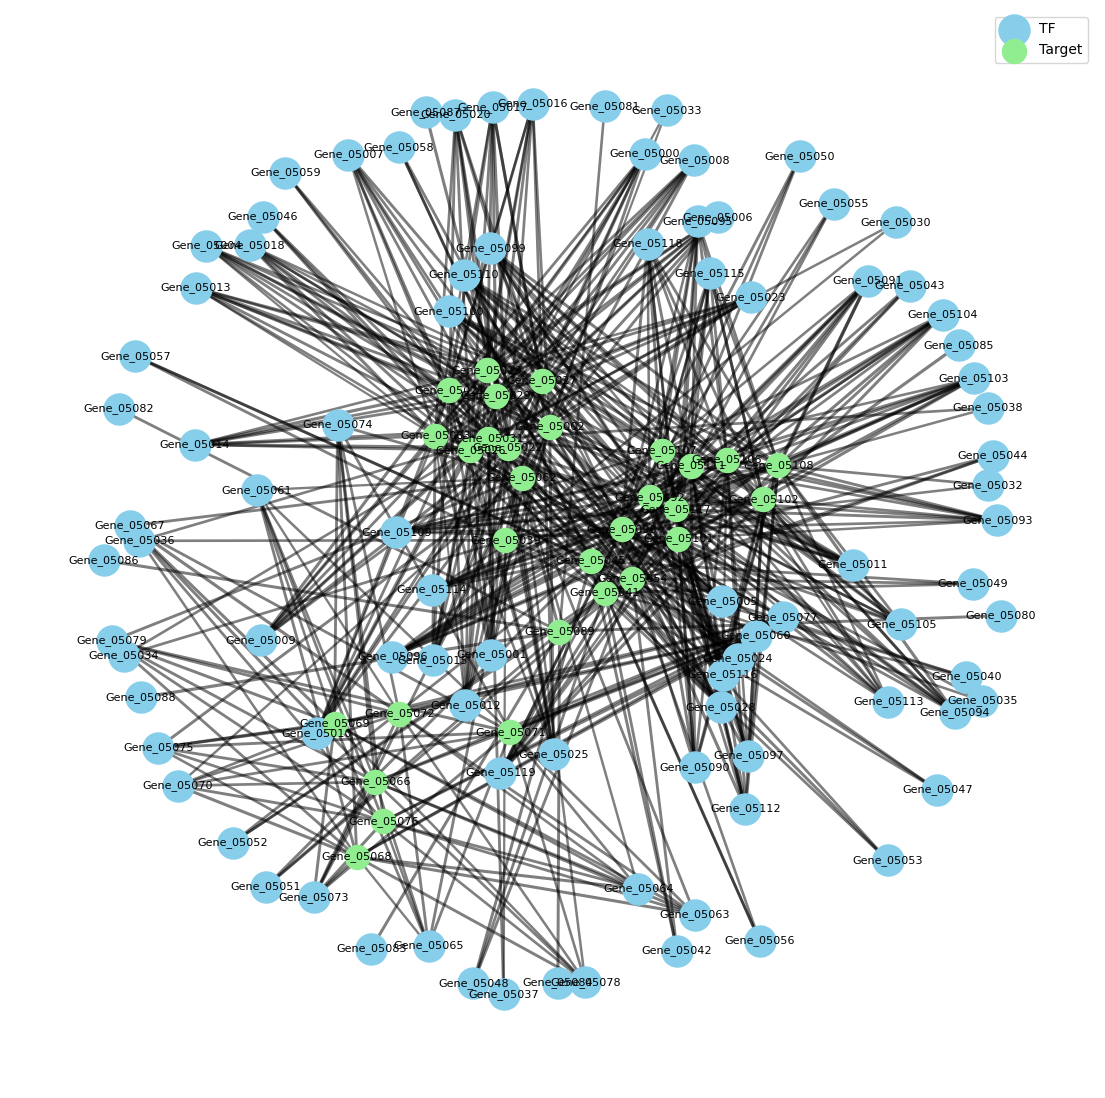

In [ ]:
# filter edges for log10BF > 1 
edges = combined_123_tftar_network[combined_123_tftar_network["log10_BF"] > 1]

# create graph
G = nx.from_pandas_edgelist(edges, source="TF", target="Target", edge_attr="log10_BF", create_using=nx.Graph())

# layout
pos = nx.spring_layout(G, k=2, iterations=100)

# identify TFs and targets
TFs = set(edges["TF"])
targets = set(edges["Target"])

# edge weights (scaled down)
edge_weights = [
    d["log10_BF"] * 0.3 
    for _, _, d in G.edges(data=True)
    ]

plt.figure(figsize=(14,14))

# draw nodes
nx.draw_networkx_nodes(G, pos, nodelist=TFs, node_color="skyblue", node_size=500, label="TF")
nx.draw_networkx_nodes(G, pos, nodelist=targets, node_color="lightgreen", node_size=300, label="Target")

# draw edges
nx.draw_networkx_edges(G, pos,width=edge_weights, alpha=0.5, arrows=True, arrowsize=10)

# labels
nx.draw_networkx_labels(G, pos, font_size=8)

plt.legend()
plt.axis("off")
plt.show()